In [74]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt

In [75]:
IMAGE_SIZE=256
BATCH_SIZE =32
CHANNELS = 3
EPOCHS=5

In [76]:
import zipfile
import os

zip_file_path = 'PlantVillage.zip'
extract_dir = 'PlantVillage'

# Create the extraction directory if it doesn't exist
if not os.path.exists(extract_dir):
    os.makedirs(extract_dir)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"'{zip_file_path}' extracted to '{extract_dir}'")

'PlantVillage.zip' extracted to 'PlantVillage'


In [77]:
# from google.colab import drive
# drive.mount('/content/drive')

In [78]:
df = tf.keras.preprocessing.image_dataset_from_directory(
    "PlantVillage/PlantVillage",
    shuffle=True,
    image_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size = BATCH_SIZE
)

Found 2152 files belonging to 3 classes.


In [79]:
class_name = df.class_names

In [80]:
len(df)

68

In [81]:
for image_batch, labels_batch in df.take(1):
    # print(image_batch.shape)
    print(image_batch[0])
    print(labels_batch.numpy())

tf.Tensor(
[[[207. 206. 212.]
  [208. 207. 213.]
  [208. 207. 213.]
  ...
  [169. 167. 178.]
  [168. 166. 177.]
  [166. 164. 175.]]

 [[207. 206. 212.]
  [209. 208. 214.]
  [210. 209. 215.]
  ...
  [165. 163. 174.]
  [167. 165. 176.]
  [168. 166. 177.]]

 [[204. 203. 209.]
  [206. 205. 211.]
  [208. 207. 213.]
  ...
  [167. 165. 176.]
  [170. 168. 179.]
  [173. 171. 182.]]

 ...

 [[160. 155. 162.]
  [145. 140. 147.]
  [141. 136. 143.]
  ...
  [130. 127. 138.]
  [155. 152. 163.]
  [150. 147. 158.]]

 [[156. 151. 158.]
  [131. 126. 133.]
  [171. 166. 173.]
  ...
  [124. 121. 132.]
  [151. 148. 159.]
  [150. 147. 158.]]

 [[152. 147. 154.]
  [142. 137. 144.]
  [170. 165. 172.]
  ...
  [119. 116. 127.]
  [127. 124. 135.]
  [139. 136. 147.]]], shape=(256, 256, 3), dtype=float32)
[0 1 0 1 2 0 0 0 2 0 0 0 1 1 1 1 0 1 1 1 0 0 0 2 0 0 1 0 1 1 0 1]


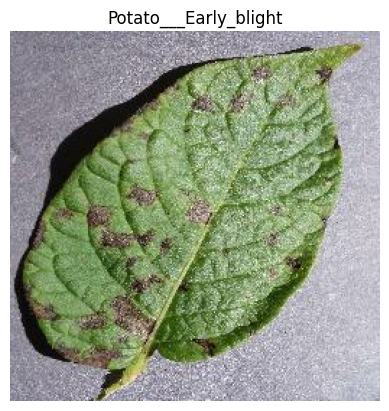

In [82]:
for image_batch, labels_batch in df.take(1):
    plt.imshow(image_batch[0].numpy().astype("uint8"))
    # plt.title(labels_batch.numpy())[0]    # it shows only numbers
    plt.title(class_name[labels_batch[0]])    # it shows name
    plt.axis("off")
    plt.show()

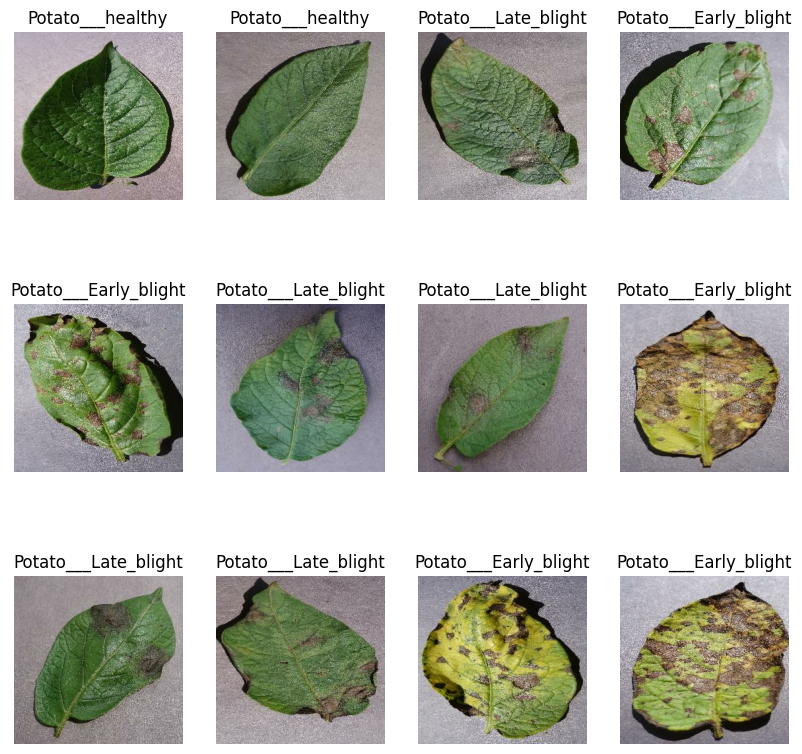

In [83]:
plt.figure(figsize=(10,10))
for image_batch, labels_batch in df.take(1):
  for i in range(12):
    ax = plt.subplot(3,4,i+1)
    plt.imshow(image_batch[i].numpy().astype("uint8"))
    plt.title(class_name[labels_batch[i]])    # it shows name
    plt.axis("off")
    # plt.show()

In [84]:
# 80% ==> training data
# 20% ==> 10% VALIDATION DATA, 10% testing

In [85]:
train_size = 0.8
len(df)*train_size

54.400000000000006

In [86]:
train_df = df.take(54)    # it take first 54 data like df[:54]
len(train_df)

54

In [87]:
test_df = df.skip(54)    # it skips the first 45 dataset like df[54:]
len(test_df)

14

In [88]:
val_df = 0.1
len(df)*val_df

6.800000000000001

In [89]:
val_df = test_df.take(6)
len(val_df)

6

In [90]:
test_df = test_df.skip(6)
len(test_df)

8

In [91]:
def got_df_partition_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):

    ds_size = len(ds)

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)

    test_size = (int)(ds_size*test_split)
    val_size = (int)(ds_size*val_split)
    train_size = (int)(ds_size*train_split)

    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size+val_size).take(test_size)
    train_ds = ds.skip(train_size+val_size+test_size)

    return train_df, val_df, test_df

In [92]:
train_df, val_df, test_df = got_df_partition_tf(df)

In [93]:
print(len(train_df))
print(len(val_df))
print(len(test_df))

54
6
8


In [94]:
train_df = train_df.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_df = val_df.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_df = test_df.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [95]:
resize_and_reshape = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1.0/255)
])

In [96]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)
])

In [97]:
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)

model = models.Sequential([
    resize_and_reshape,
    data_augmentation,
    layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(3, activation='softmax')
])

model.build(input_shape=input_shape)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [98]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_6 (Sequential)       │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_7 (Sequential)       │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (32, 28, 28, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (32, 12, 12, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (32, 6, 6, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (32, 4, 4, 64)         │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (32, 2, 2, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (32, 256)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (32, 64)               │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (32, 3)                │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

In [99]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [100]:
history = model.fit(
    train_df,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    validation_data=val_df
)

Epoch 1/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 142s 3s/step - accuracy: 0.4988 - loss: 0.8952 - val_accuracy: 0.4271 - val_loss: 1.0127
Epoch 2/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - accuracy: 0.6771 - loss: 0.7003 - val_accuracy: 0.6146 - val_loss: 0.7374
Epoch 3/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - accuracy: 0.7818 - loss: 0.5157 - val_accuracy: 0.8125 - val_loss: 0.4602
Epoch 4/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.8600 - loss: 0.3345 - val_accuracy: 0.8438 - val_loss: 0.3923
Epoch 5/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 138s 3s/step - accuracy: 0.8981 - loss: 0.2588 - val_accuracy: 0.8542 - val_loss: 0.3634


In [102]:
score = model.evaluate(test_df)

8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 636ms/step - accuracy: 0.8793 - loss: 0.3180


In [103]:
score

[0.31801119446754456, 0.8793103694915771]

In [104]:
history.params

{'verbose': 1, 'epochs': 5, 'steps': 54}

In [105]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [106]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

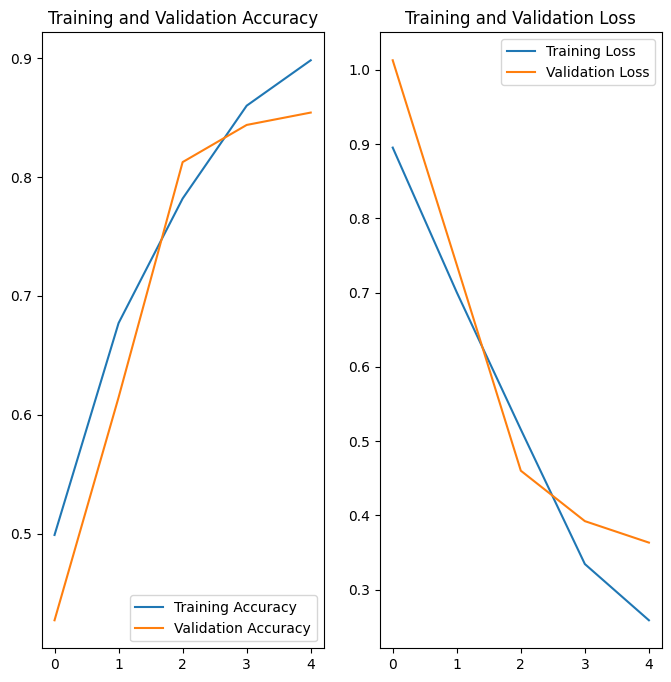

In [108]:
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1,2,2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

first image to predict
actual label: Potato___Late_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 637ms/step
[0.38718832 0.58740383 0.02540789]
predicted label: Potato___Late_blight


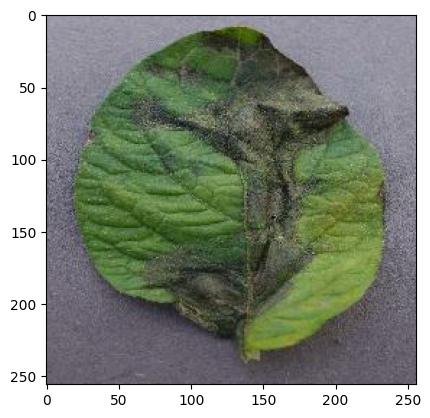

In [118]:
import numpy as np

for images_batch, labels_batch in test_df.take(1):

    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()

    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:", class_name[first_label])

    batch_prediction = model.predict(images_batch)
    print(batch_prediction[0])
    print("predicted label:", class_name[np.argmax(batch_prediction[0])])

In [131]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_name[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


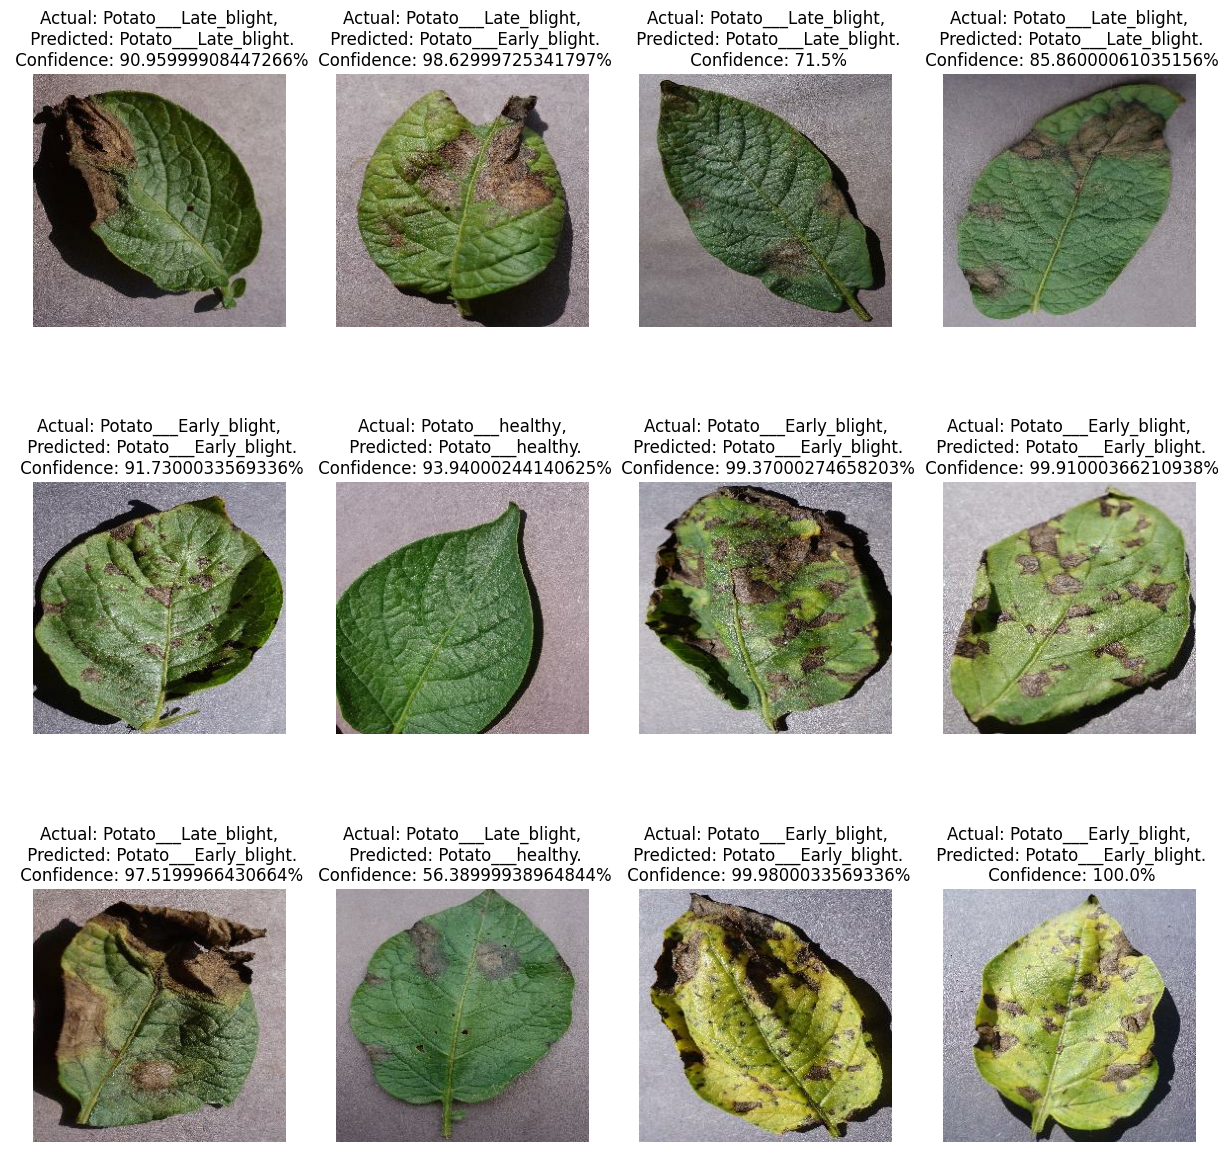

In [144]:
plt.figure(figsize=(15,15))
for image, label in test_df.take(1):
  for i in range(min(12, image.shape[0])):
    ax = plt.subplot(3,4,i+1)
    plt.imshow(image[i].numpy().astype("uint8"))
    plt.axis("off")
    predicted_class, confidence = predict(model, image[i].numpy())
    actual_class = class_name[label[i]]
    plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")

In [143]:
import os
model_version=max([int(i) for i in os.listdir("/") + [0]])+1
model.save(f"../models/{model_version}")

In [139]:
model.version=1
model.save(f"{model.version}.keras")